# NASA CMAPSS — Exploratory Data Analysis

**Dataset:** NASA CMAPSS Turbofan Engine Degradation Simulation  
**Goal:** Understand the 21 sensors, operating conditions, and failure patterns before building any models.

## How to get the data
Run the download script from the repo root — it fetches all 12 files automatically:

```bash
python scripts/download_cmapss.py
```

Files will be saved to `data/raw/`:
```
data/raw/train_FD001.txt  ...  train_FD004.txt
data/raw/test_FD001.txt   ...  test_FD004.txt
data/raw/RUL_FD001.txt    ...  RUL_FD004.txt
```

## The 4 sub-datasets
| Dataset | Operating Conditions | Fault Modes |
|---------|---------------------|-------------|
| FD001   | 1                   | 1 (HPC degradation) |
| FD002   | 6                   | 1 |
| FD003   | 1                   | 2 |
| FD004   | 6                   | 2 |

We start with **FD001** — simplest case, 1 condition, 1 fault mode.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Make plots look clean
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data/raw')

## 1. Load the data

The files have **no header row** and are space-separated.  
There are 26 columns: engine_id, cycle, 3 operational settings, 21 sensor readings.

In [2]:
# Column names — memorize these, you'll use them everywhere
COLUMNS = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1, 4)]
    + [f'sensor_{i}' for i in range(1, 22)]
)

def load_cmapss(filename):
    """Load a CMAPSS txt file into a DataFrame."""
    return pd.read_csv(
        DATA_DIR / filename,
        sep=r'\s+',   # space-separated
        header=None,
        names=COLUMNS
    )

train = load_cmapss('train_FD001.txt')
test  = load_cmapss('test_FD001.txt')

# RUL labels for the test set (one number per engine = RUL at last cycle)
rul_test = pd.read_csv(DATA_DIR / 'RUL_FD001.txt', header=None, names=['rul'])

print(f'Train shape: {train.shape}')   # expect (20631, 26)
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (20631, 26)
Test shape:  (13096, 26)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


You have 100 engines in the training set. Each engine was run until it broke. Every row is one "reading" — like a snapshot of all 21 sensors at one moment in time. 20,631 total snapshots across all 100 engines. The 26 columns are: engine ID, cycle number, 3 operating settings, 21 sensor values.

Cycle = one unit of time in this dataset. Think of it like "one flight" or "one hour of operation."

## 2. Basic statistics

In [3]:
# How many engines? How long do they run?
engine_stats = (
    train.groupby('engine_id')['cycle']
    .max()
    .rename('max_cycle')
    .describe()
)
print('Engine lifespan stats (cycles):')
print(engine_stats)
print(f'\nTotal engines: {train["engine_id"].nunique()}')

Engine lifespan stats (cycles):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64

Total engines: 100


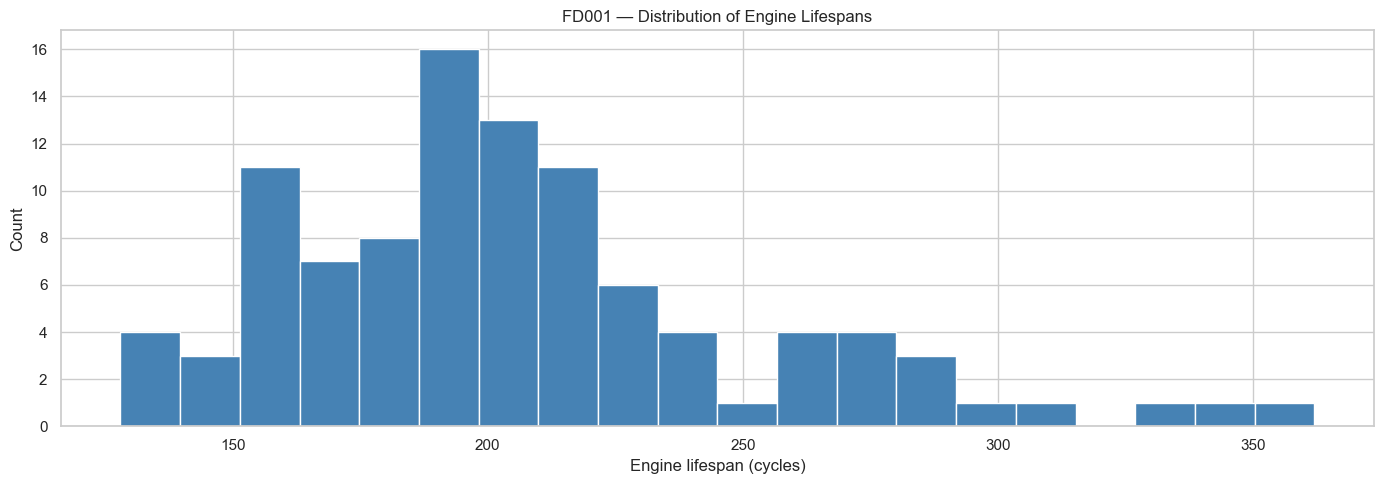

Shortest-lived engine: 128 cycles
Longest-lived engine:  362 cycles
Median:                199 cycles


In [4]:
# Distribution of engine lifespans
max_cycles = train.groupby('engine_id')['cycle'].max()

plt.figure()
plt.hist(max_cycles, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Engine lifespan (cycles)')
plt.ylabel('Count')
plt.title('FD001 — Distribution of Engine Lifespans')
plt.tight_layout()
plt.show()

print(f'Shortest-lived engine: {max_cycles.min()} cycles')
print(f'Longest-lived engine:  {max_cycles.max()} cycles')
print(f'Median:                {max_cycles.median():.0f} cycles')

Some engines died young (128 cycles), some lived long (362 cycles). Average lifespan is ~206 cycles. This variation is realistic — machines in the real world don't all fail at the same time.

The histogram shows most engines cluster around 150–250 cycles. A few outliers live much longer. This tells you your model can't just say "flag after 200 cycles" — it needs to actually detect degradation.

## 3. Compute Remaining Useful Life (RUL)

For training data, we know exactly when each engine failed (last cycle = failure).  
RUL at any cycle = `max_cycle_for_that_engine - current_cycle`.

In [5]:
# Add RUL column to training data
max_cycle_per_engine = train.groupby('engine_id')['cycle'].max().rename('max_cycle')
train = train.merge(max_cycle_per_engine, on='engine_id')
train['rul'] = train['max_cycle'] - train['cycle']
train = train.drop(columns=['max_cycle'])

print('RUL distribution:')
print(train['rul'].describe())

# Quick sanity check: last cycle of any engine should have RUL = 0
assert train.groupby('engine_id')['rul'].min().eq(0).all(), 'RUL calc wrong!'
print('\nSanity check passed: all engines reach RUL = 0')

RUL distribution:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul, dtype: float64

Sanity check passed: all engines reach RUL = 0


RUL = how many cycles until this engine breaks. At the very first reading of an engine, RUL is high (lots of life left). At the last reading, RUL = 0 (it just failed). The sanity check confirms your math is right — every engine's final row has RUL = 0.

Why this matters: Your whole system's job is to detect when RUL is getting dangerously low before the engineer can see it just by looking at the numbers.

## 4. Sensor time series — what does degradation look like?

Plot all 21 sensors for one engine. You'll see some sensors degrade clearly,  
others are flat/noisy/constant. The flat ones are candidates to drop later.

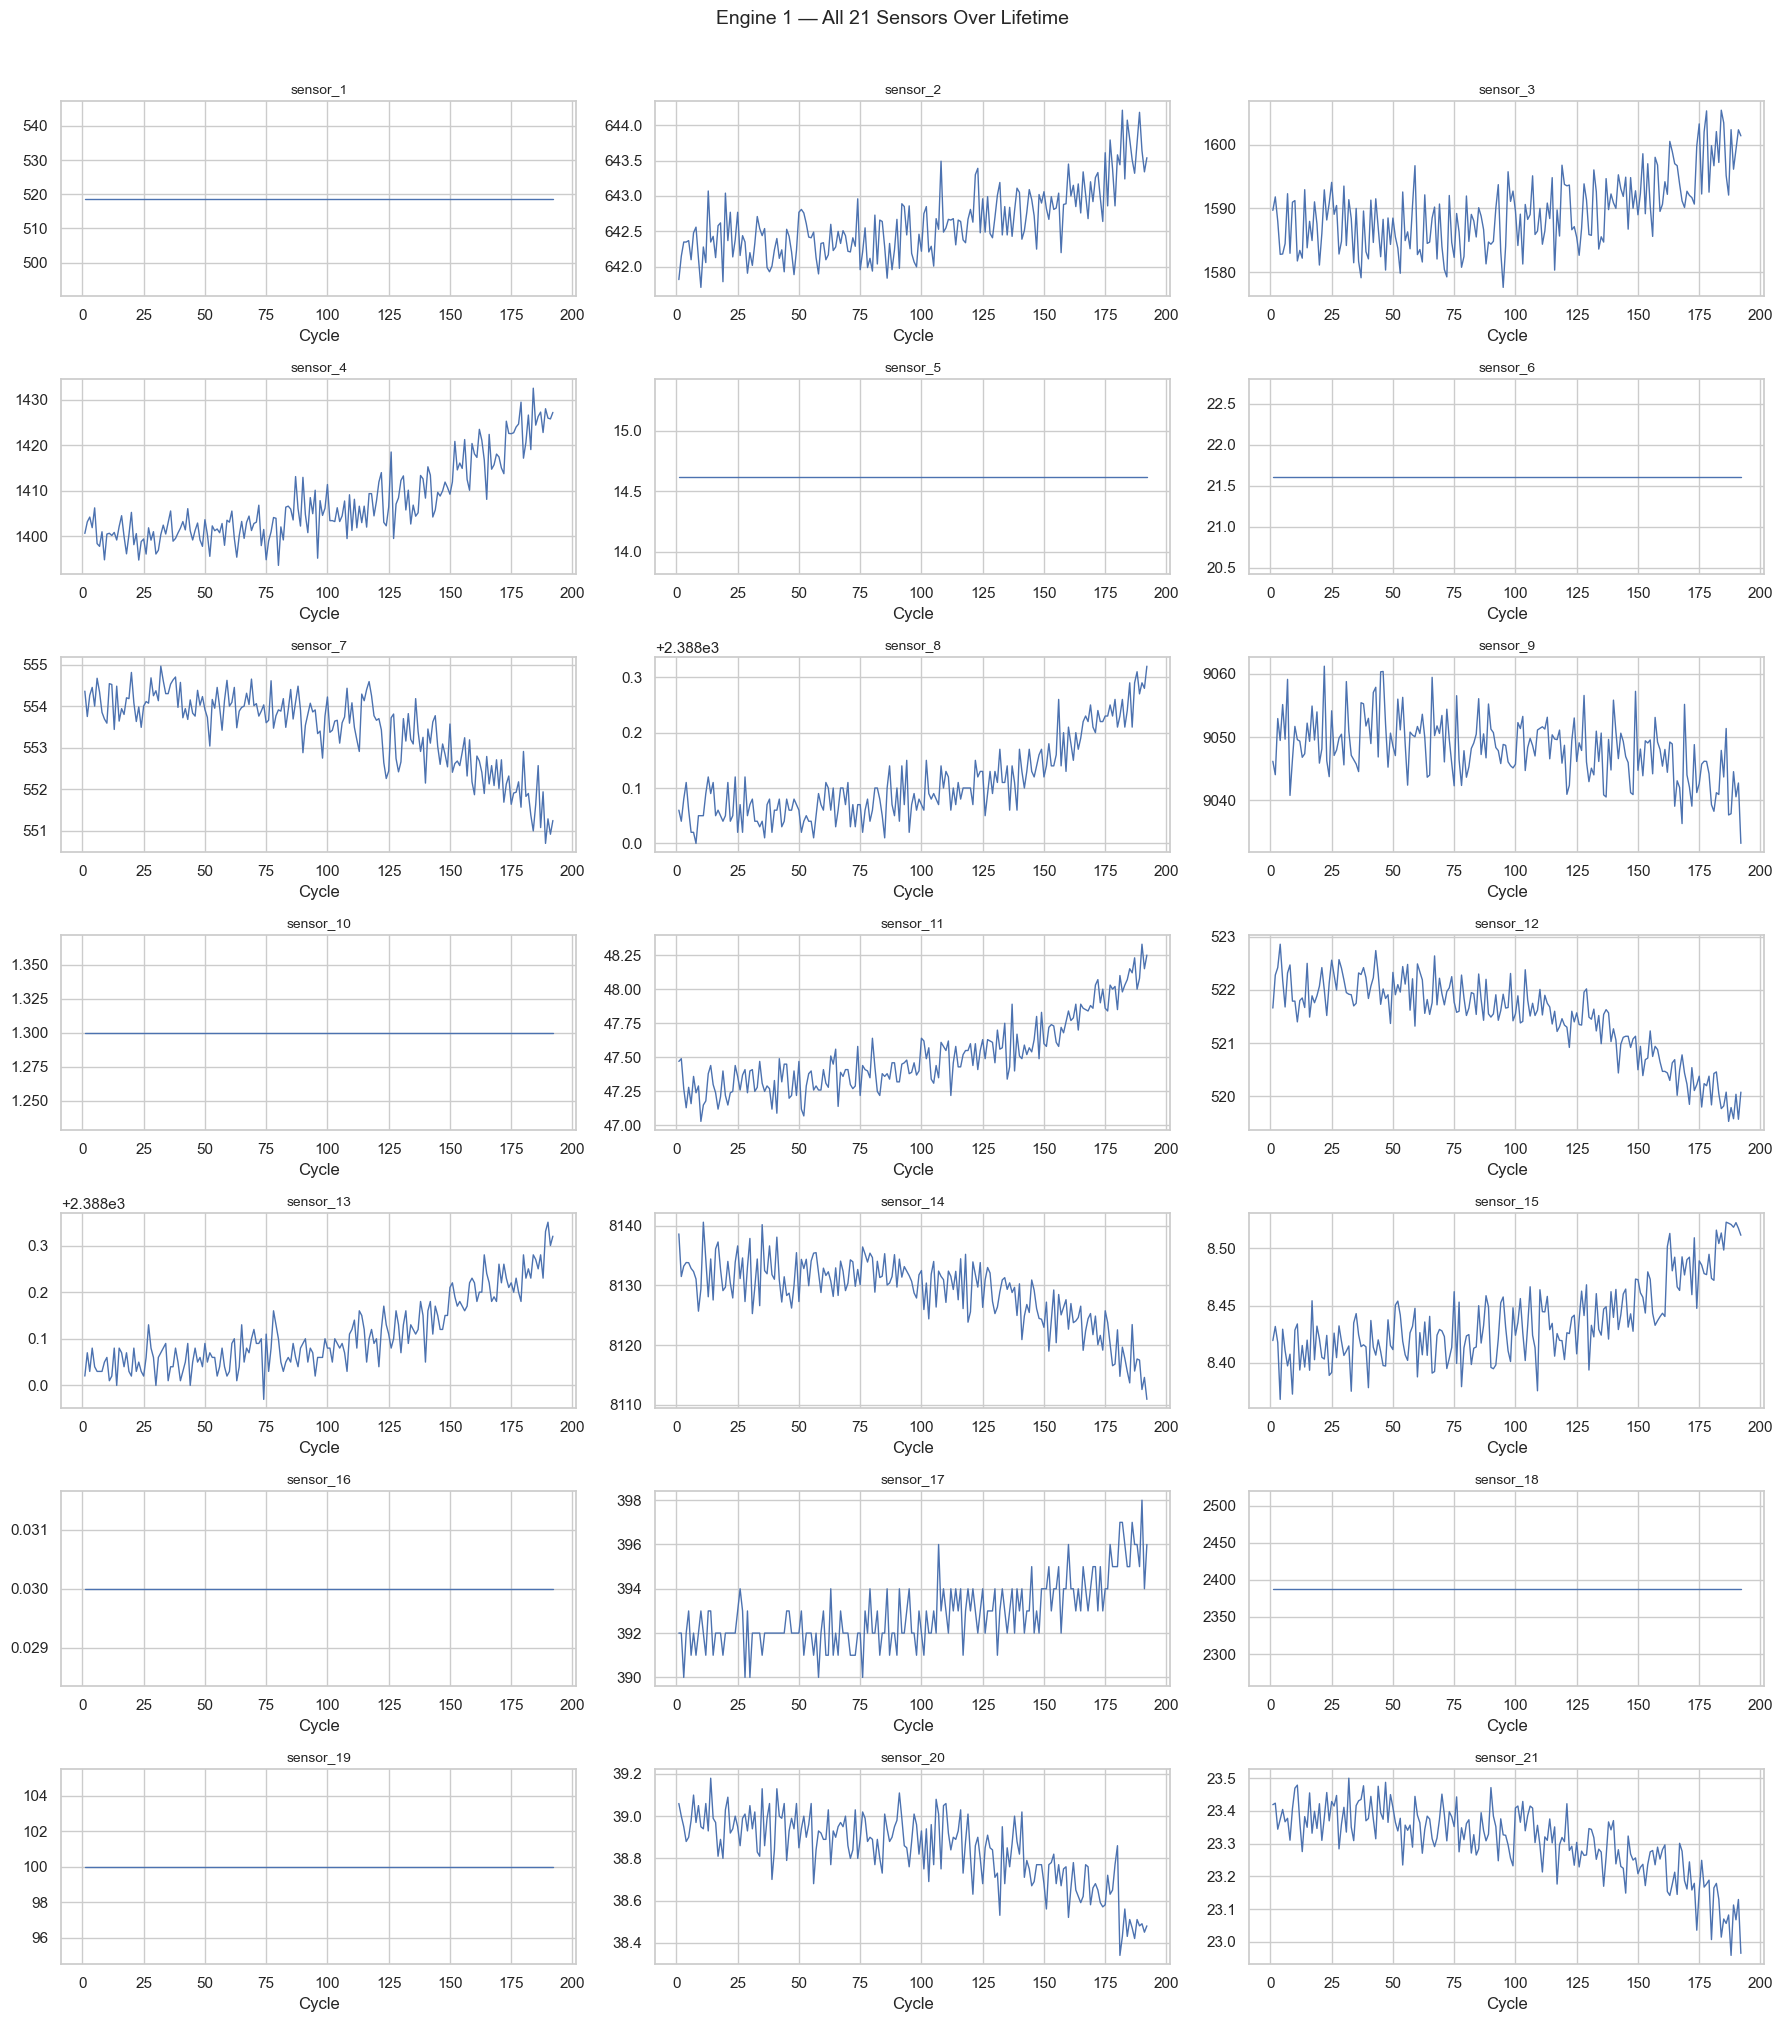

In [6]:
ENGINE_ID = 1  # change this to look at other engines
engine_data = train[train['engine_id'] == ENGINE_ID].sort_values('cycle')

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(18, 20))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    axes[i].plot(engine_data['cycle'], engine_data[sensor], linewidth=1)
    axes[i].set_title(sensor, fontsize=10)
    axes[i].set_xlabel('Cycle')

# hide the last 2 empty subplots
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Engine {ENGINE_ID} — All 21 Sensors Over Lifetime', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

You'll see 21 small charts. Look for three patterns:

Trending sensors (line goes up or down as cycles increase) — these are your gold. Sensors 2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21 typically show clear trends. These are the early warning signals.
Flat sensors (horizontal line) — sensors 1, 5, 6, 10, 16, 18, 19 barely change at all. They're like a thermometer that's stuck. Useless for predicting failure.
Noisy sensors (jagged up and down) — some signal but hard to use directly. Models can still extract patterns from these.
The key insight: Only about half the sensors actually tell you something useful. The rest are noise.

## 5. Identify near-constant sensors (candidates to drop)

Sensors with very low standard deviation carry no information.  
We'll flag any sensor where `std < 0.01` across the full training set.

In [7]:
sensor_std = train[sensor_cols].std().sort_values()

print('Sensor standard deviations (ascending):')
print(sensor_std.to_string())

low_variance = sensor_std[sensor_std < 0.01].index.tolist()
print(f'\nNear-constant sensors (std < 0.01): {low_variance}')
print('These are safe to drop — they add noise without information.')

Sensor standard deviations (ascending):
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01

Near-constant sensors (std < 0.01): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6']
These are safe to drop — they add noise without information.


These 7 sensors have almost zero variation across all 20,000+ readings. Standard deviation measures how much a value moves around — near zero means it barely moves.

The bar chart makes this visual. You'll see most sensors have moderate height bars, but these 7 are nearly invisible at the bottom. You'll drop these later when building the model — they'd just confuse it.

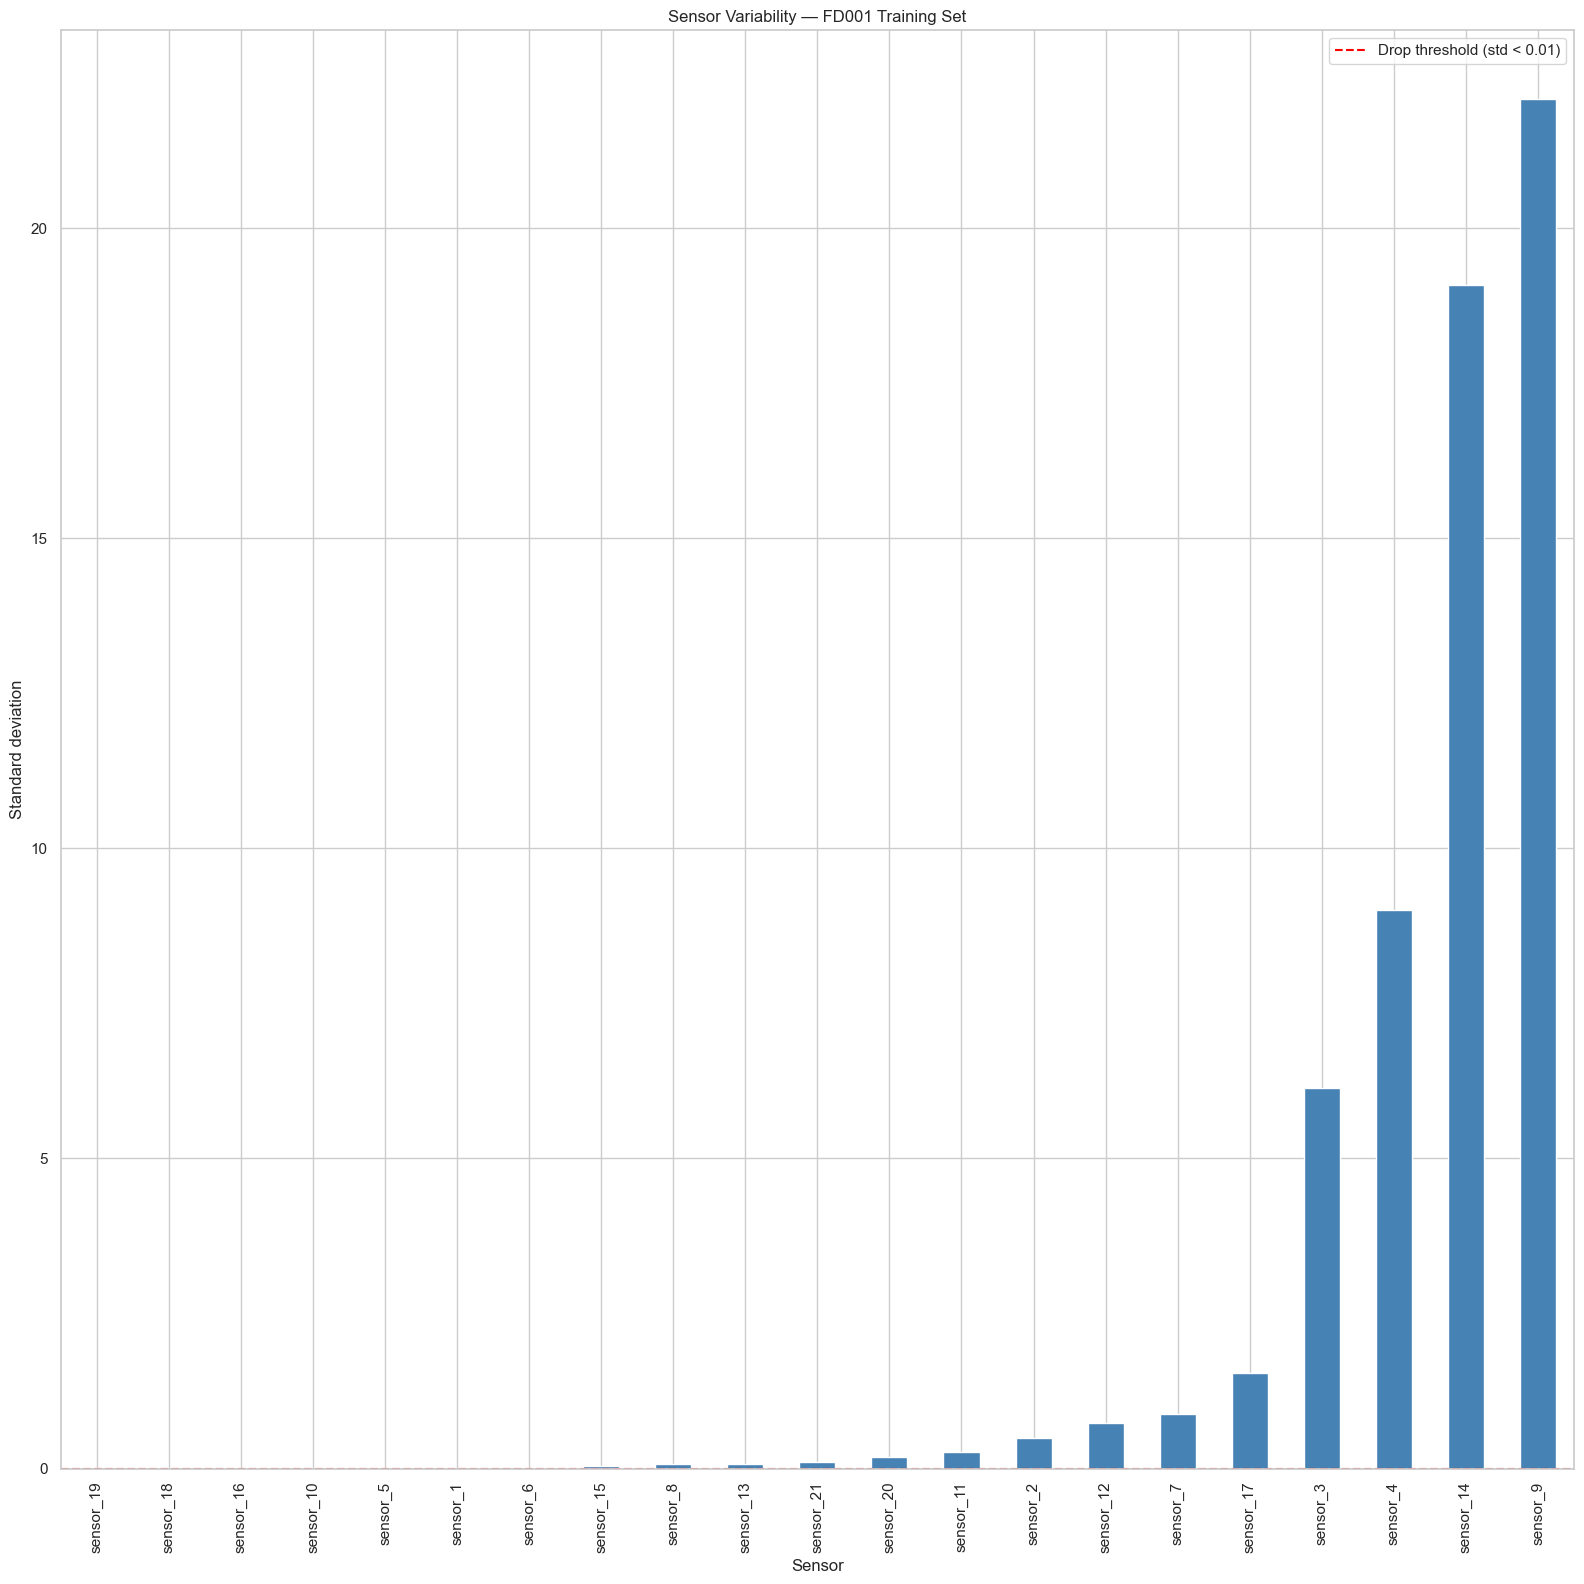

In [21]:
# Bar chart of sensor variability
plt.figure(figsize=(16, 16))
sensor_std.plot(kind='bar', color='steelblue')
plt.axhline(y=0.001, color='red', linestyle='--', label='Drop threshold (std < 0.01)')
plt.xlabel('Sensor')
plt.ylabel('Standard deviation')
plt.title('Sensor Variability — FD001 Training Set')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Correlation between sensors

High correlation between sensors is expected — they're measuring the same physical system.  
This also tells us which sensors might be thermodynamically linked (important for the causal DAG later).

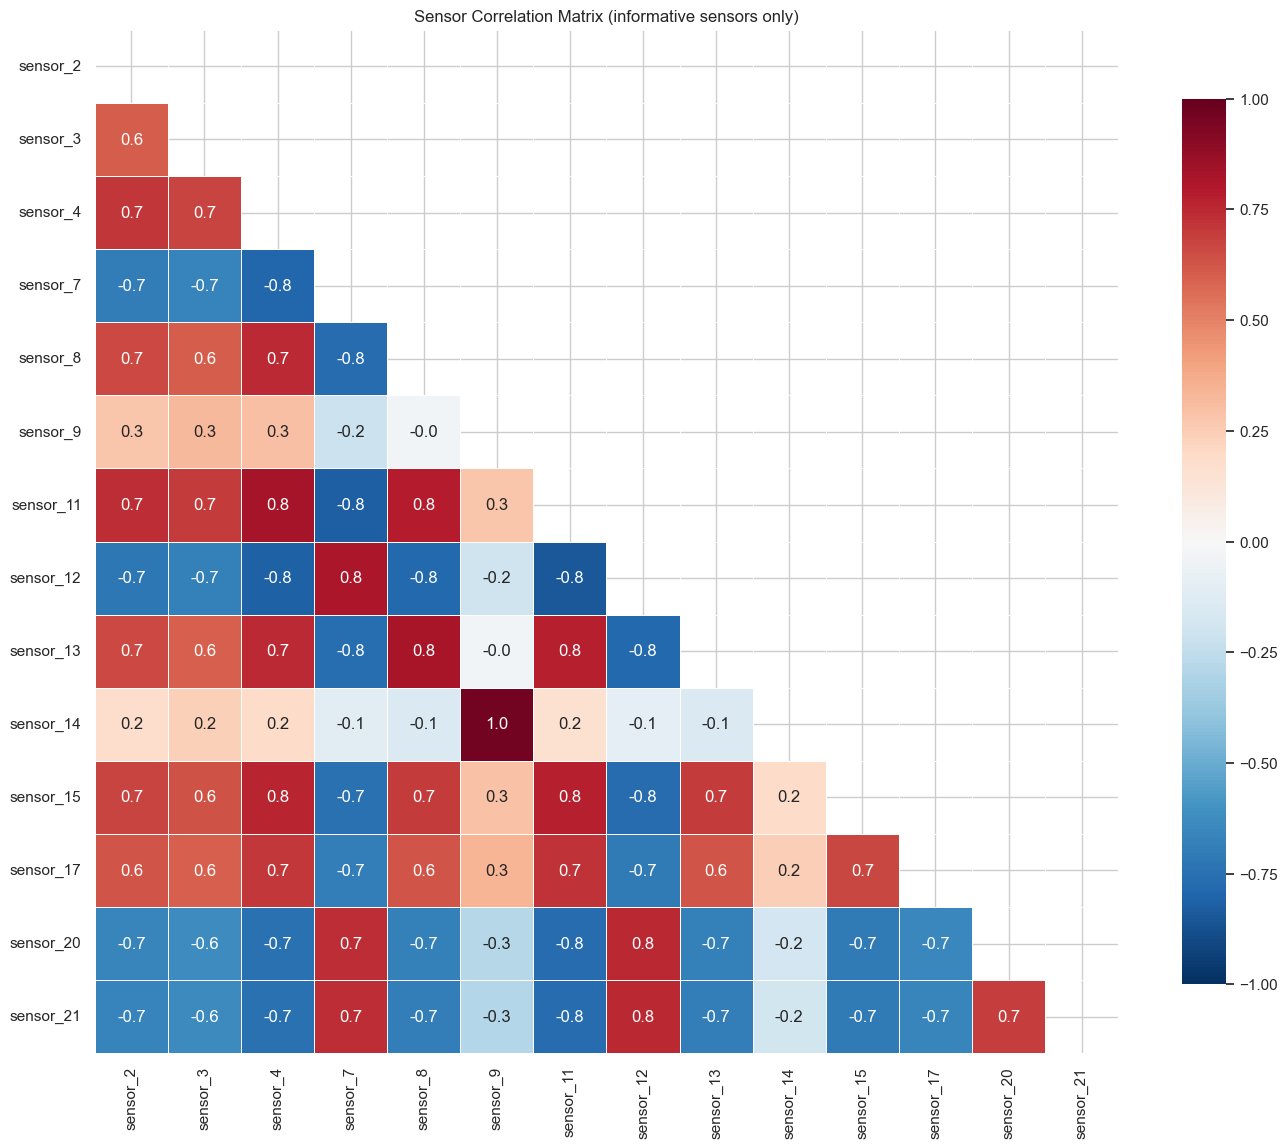

In [9]:
# Use only the informative sensors (drop near-constant ones)
informative_sensors = [s for s in sensor_cols if s not in low_variance]

corr = train[informative_sensors].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.1f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Sensor Correlation Matrix (informative sensors only)')
plt.tight_layout()
plt.show()

A grid where each square shows how two sensors move together. Colors:

- Dark red (+1.0) = they always move together (when one goes up, so does the other)
- Dark blue (-1.0) = they always move opposite (one goes up, other goes down)
- White (0.0) = no relationship

You'll see clusters of strongly correlated sensors. For example, temperature sensors tend to move together because they're measuring the same physical system from different angles. This is important for your causal DAG later — those correlated pairs are likely thermodynamically linked (in an HPC, temperature and pressure are governed by the isentropic compression relation T₂/T₁ = (P₂/P₁)^((γ−1)/γ), γ ≈ 1.4 for air — both must rise together through the compressor).

## 7. How does a sensor change as the engine approaches failure?

Instead of plotting by cycle, plot by RUL (time-to-failure).  
This reveals which sensors are the **earliest warning signals**.

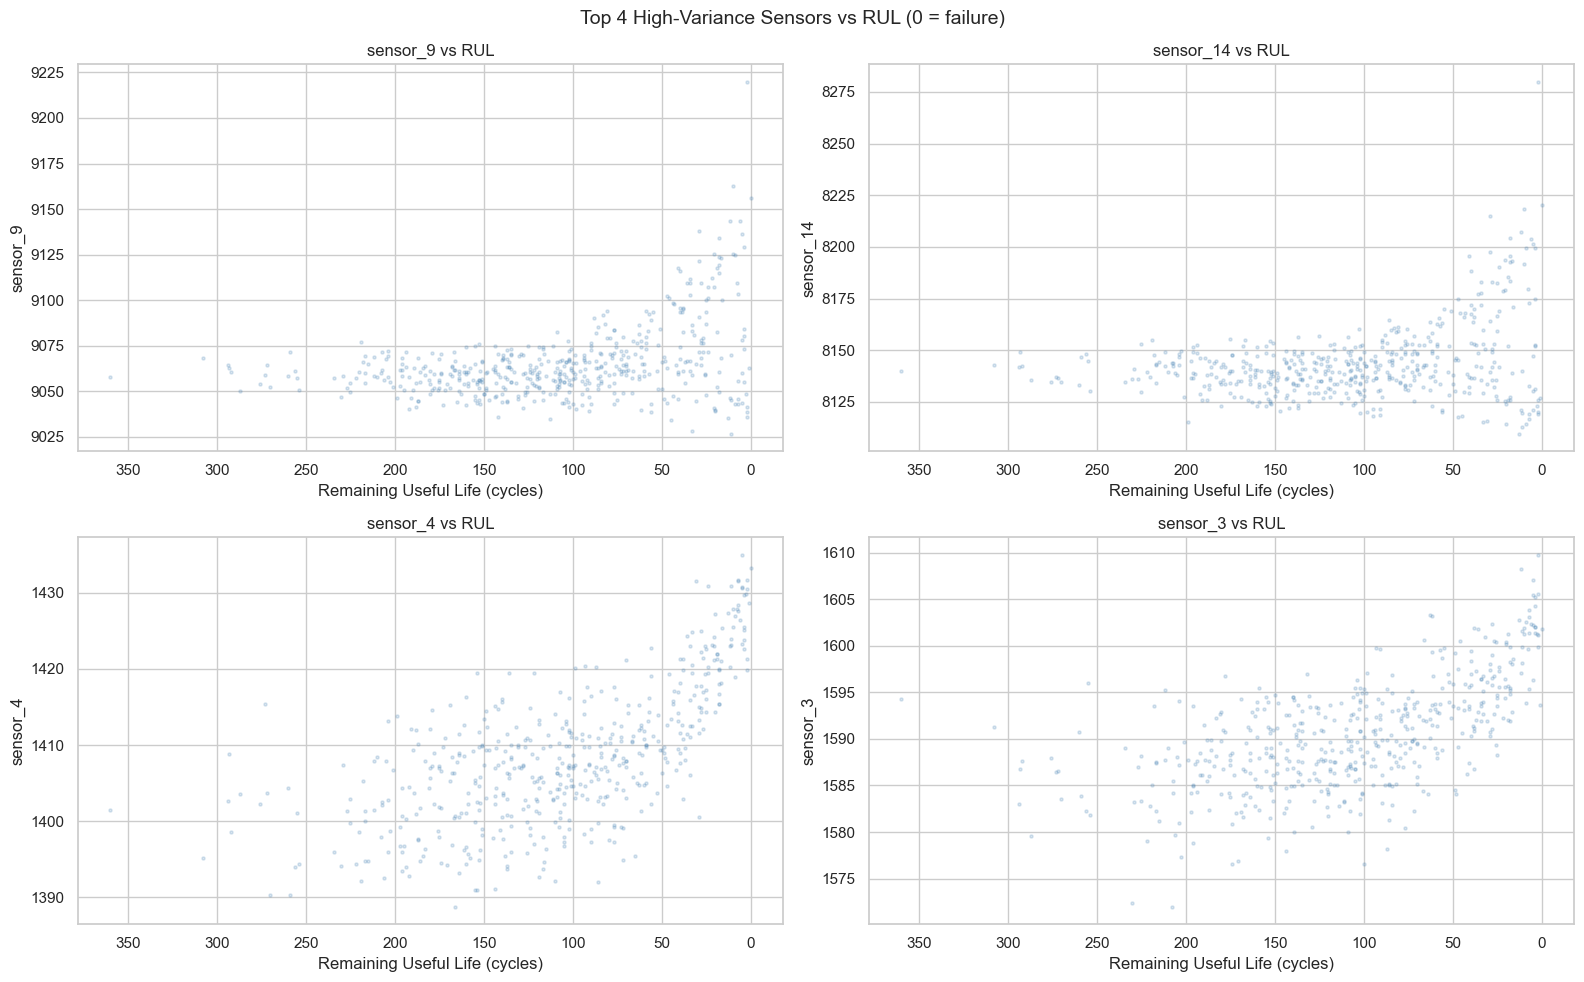

Sensors that trend clearly toward failure = strong degradation signals
Sensors that look random vs RUL = noise or operational variation


In [10]:
# Pick 4 sensors that showed the most variance
top_sensors = sensor_std.nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    # Sample 500 random rows so the plot isn't too dense
    sample = train.sample(min(500, len(train)), random_state=42)
    axes[i].scatter(sample['rul'], sample[sensor], alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel('Remaining Useful Life (cycles)')
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f'{sensor} vs RUL')
    axes[i].invert_xaxis()  # 0 = failure on the right

fig.suptitle('Top 4 High-Variance Sensors vs RUL (0 = failure)', fontsize=14)
plt.tight_layout()
plt.show()

print('Sensors that trend clearly toward failure = strong degradation signals')
print('Sensors that look random vs RUL = noise or operational variation')

Each dot is one reading. X-axis = RUL (0 = failure, on the right side since axis is flipped). Y-axis = sensor value.

What you want to see: A clear slope — sensor value trends up or down as RUL approaches 0. If you see a diagonal cloud of dots, that sensor is an early warning signal.

What bad looks like: A random blob with no slope — the sensor is just noise relative to failure prediction.

The top 4 high-variance sensors typically show clear trends. This is your visual proof that degradation is detectable before failure.

## 8. Operating conditions (FD002 comparison)

FD001 has only 1 operating condition — the op_settings are nearly constant.  
FD002 has 6 conditions, which is where our causal model's altitude/Mach root nodes matter.  
Let's look at both to see the difference.

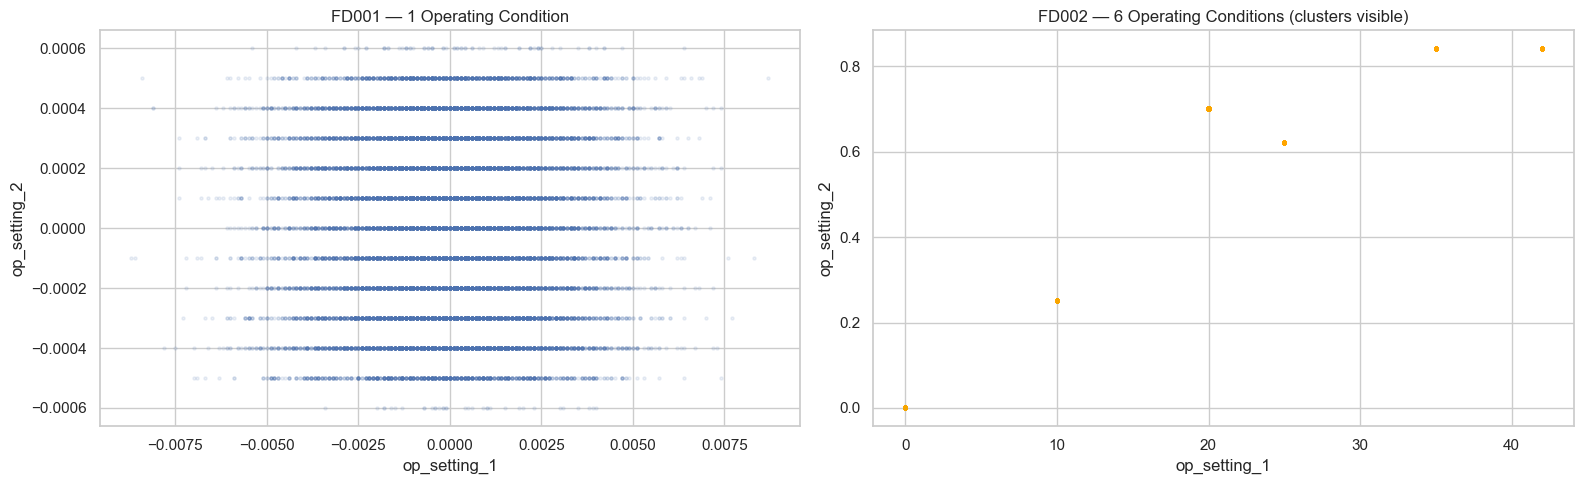

FD002 clusters = different altitude/throttle regimes
This is WHY we need regime-conditional anomaly detection.
A sensor reading normal at one condition might be abnormal at another.


In [11]:
train_fd002 = load_cmapss('train_FD002.txt')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(train['op_setting_1'], train['op_setting_2'], alpha=0.1, s=5)
axes[0].set_title('FD001 — 1 Operating Condition')
axes[0].set_xlabel('op_setting_1')
axes[0].set_ylabel('op_setting_2')

axes[1].scatter(train_fd002['op_setting_1'], train_fd002['op_setting_2'], alpha=0.1, s=5, color='orange')
axes[1].set_title('FD002 — 6 Operating Conditions (clusters visible)')
axes[1].set_xlabel('op_setting_1')
axes[1].set_ylabel('op_setting_2')

plt.tight_layout()
plt.show()

print('FD002 clusters = different altitude/throttle regimes')
print('This is WHY we need regime-conditional anomaly detection.')
print('A sensor reading normal at one condition might be abnormal at another.')

Two scatter plots of op_setting_1 vs op_setting_2.

- FD001 looks like one tight blob — all readings were taken under the same conditions (same altitude, same throttle). Simple.
- FD002 shows 6 distinct clusters — readings were taken under 6 different flight conditions (different altitudes, different speeds).

Why this matters for your project: If you train a model only on FD001 (one condition), it learns "sensor_7 above 550 = bad." But in FD002, sensor_7 might naturally be 580 at high altitude and that's completely normal. Your causal model needs to know what condition the engine is in before deciding if a reading is abnormal. Those 6 clusters are why altitude/Mach/TRA are root nodes in your causal DAG.

## 9. Summary — what we learned

Run this cell to print a summary you can reference when building the schema and models.

In [12]:
print('=== CMAPSS FD001 EDA Summary ===')
print(f'Training rows:       {len(train):,}')
print(f'Training engines:    {train["engine_id"].nunique()}')
print(f'Total sensors:       21')
print(f'Near-constant sensors (drop candidates): {low_variance}')
print(f'Informative sensors: {len(informative_sensors)}')
print(f'Avg engine lifespan: {max_cycles.mean():.0f} cycles')
print()
print('=== Key insights for system design ===')
print('1. RUL label = max_cycle - current_cycle (you compute this, it is not in the file)')
print('2. Sensors 1, 5, 6, 10, 16, 18, 19 are typically near-constant — safe to drop')
print('3. FD002/FD004 have 6 operating condition clusters — need regime-conditional scoring')
print('4. op_setting_1/2/3 map to altitude/Mach/TRA — root nodes in our causal DAG')
print('5. Thermodynamically linked sensor pairs will show correlated drift when engine degrades')

=== CMAPSS FD001 EDA Summary ===
Training rows:       20,631
Training engines:    100
Total sensors:       21
Near-constant sensors (drop candidates): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6']
Informative sensors: 14
Avg engine lifespan: 206 cycles

=== Key insights for system design ===
1. RUL label = max_cycle - current_cycle (you compute this, it is not in the file)
2. Sensors 1, 5, 6, 10, 16, 18, 19 are typically near-constant — safe to drop
3. FD002/FD004 have 6 operating condition clusters — need regime-conditional scoring
4. op_setting_1/2/3 map to altitude/Mach/TRA — root nodes in our causal DAG
5. Thermodynamically linked sensor pairs will show correlated drift when engine degrades


This is your reference card for the rest of the project. 14 informative sensors out of 21 — that's what your schema, models, and agent will actually care about.